In [1]:
%reload_ext autoreload
%autoreload 2

from interpolation_uncertainty.core.loadfile import load_file
from interpolation_uncertainty.processors import preProcessors
from interpolation_uncertainty.utils import utils
import numpy as np
from matplotlib import pyplot as plt

### Read BAG file

- integrate changes in reading Raster Files
- no more preprocessing when reading raster files

Warning 1: cornerPoints not consistent with resolution given in metadata


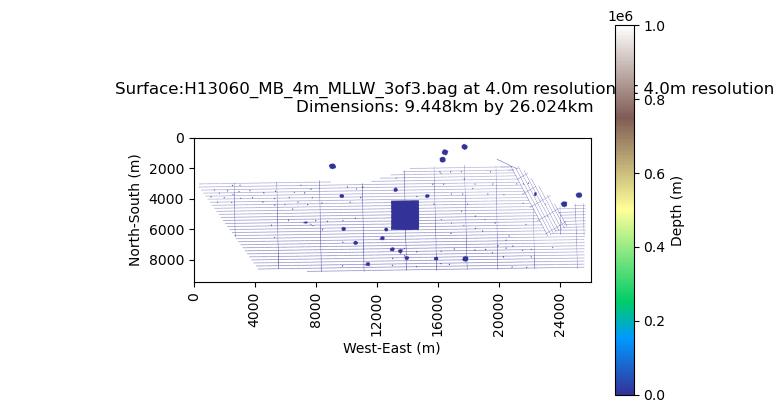

In [2]:
fn = r"/Users/francis/Downloads/H13060_MB_4m_MLLW_3of3.bag"
bathy_data = load_file(fn)
bathy_data.show_depth()


### Transform Raster to point list using geotransform metadata

In [3]:
print(bathy_data.metadata)

{'ndv_value': 1000000.0, 'resolution': 4.0, 'full_path': '/Users/francis/Downloads/H13060_MB_4m_MLLW_3of3.bag', 'geotransform': (302698.0, 4.0, 0.0, 3361470.0, 0.0, -4.0)}


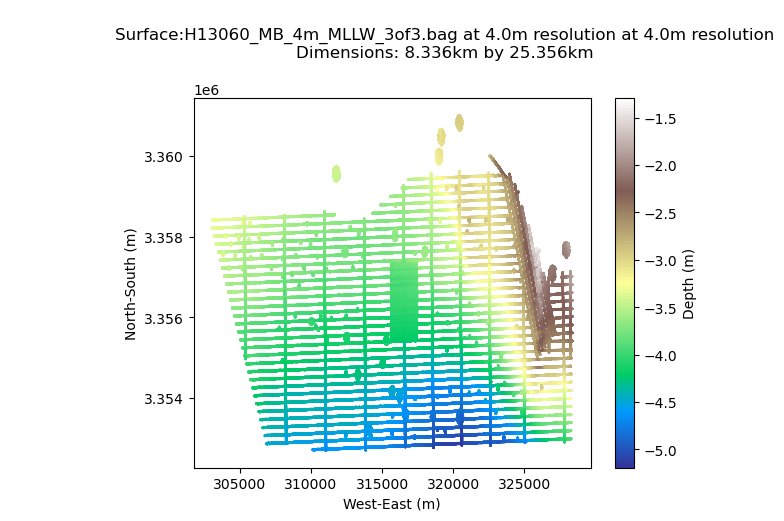

In [4]:
bathy_data_points = preProcessors.raster_to_points(bathy_data)
bathy_data_points.show_depth()

In [ ]:
import random

percentage = 0.01  # Use 1% of the data for clustering
X = np.array(bathy_data_points[:, :2])  # Use only the x and y coordinates for clustering
subset = int(len(X) * percentage)  # Use a subset of the data for faster computation
subset_indices = random.sample(range(len(X)), subset)
X_subset = X[subset_indices, :]

### Clustering

- different densities
- clear partition between high and low density



### K-Means

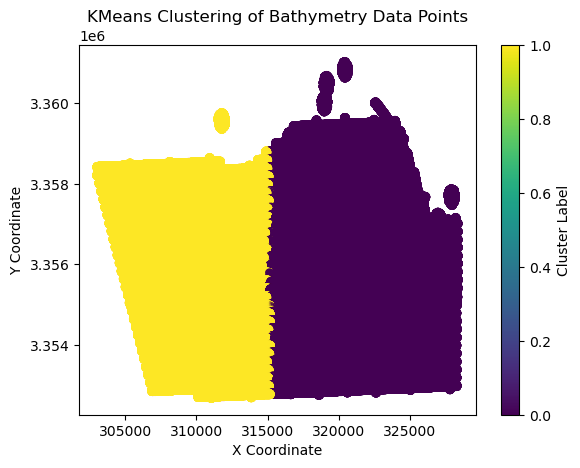

In [ ]:
from sklearn.cluster import KMeans

kmeans_2 = KMeans(n_clusters=2, init='k-means++', random_state=0, n_init=10)

kmeans_labels = kmeans_2.fit_predict(X)

# plotting the clusters
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=1)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('KMeans Clustering of Bathymetry Data Points')
plt.colorbar(label='Cluster Label')
plt.show()

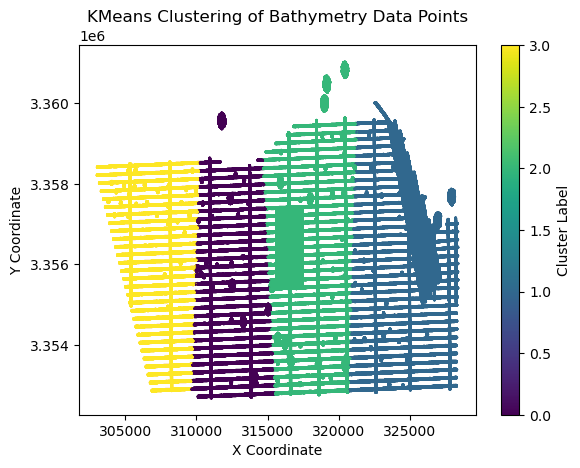

In [16]:
from sklearn.cluster import KMeans
kmeans_4 = KMeans(n_clusters=4, init='k-means++', random_state=0, n_init=10)

kmeans_labels = kmeans_4.fit_predict(X)

# plotting the clusters
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=1)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('KMeans Clustering of Bathymetry Data Points')
plt.colorbar(label='Cluster Label')
plt.show()

### DBSCAN

In [10]:
from sklearn.cluster import DBSCAN, SpectralClustering

dbscan = DBSCAN(eps=8, min_samples=10).fit(X)
labels_dbscan = dbscan.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_ = list(labels_dbscan).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 47
Estimated number of noise points: 12


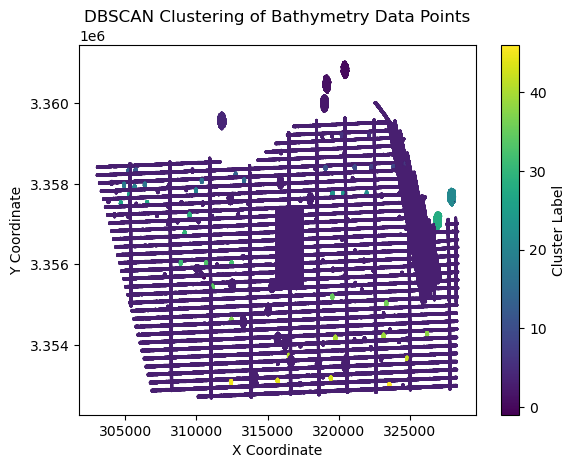

In [11]:
# plotting the clusters
plt.scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap='viridis', marker='o', s=1)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('DBSCAN Clustering of Bathymetry Data Points')
plt.colorbar(label='Cluster Label')
plt.show()

### OPTICS

In [13]:
from sklearn.cluster import OPTICS

optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.1)
labels_optics = optics.fit_predict(X_subset)

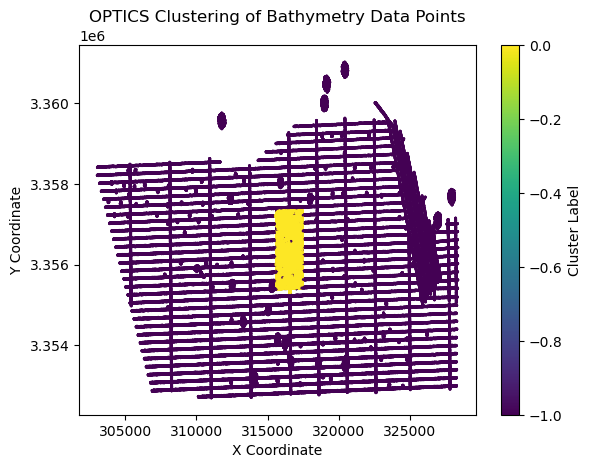

In [14]:
# plotting the clusters
plt.scatter(X_subset[:, 0], X_subset[:, 1], c=labels_optics, cmap='viridis', s=1)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('OPTICS Clustering of Bathymetry Data Points')
plt.colorbar(label='Cluster Label')
plt.show()

### HDBSCAN

In [17]:
from sklearn.cluster import HDBSCAN
hdbscan = HDBSCAN(min_samples=10, min_cluster_size=20)
labels_hdbscan = hdbscan.fit_predict(X_subset)


/opt/anaconda3/envs/interpolation_uncertainty/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


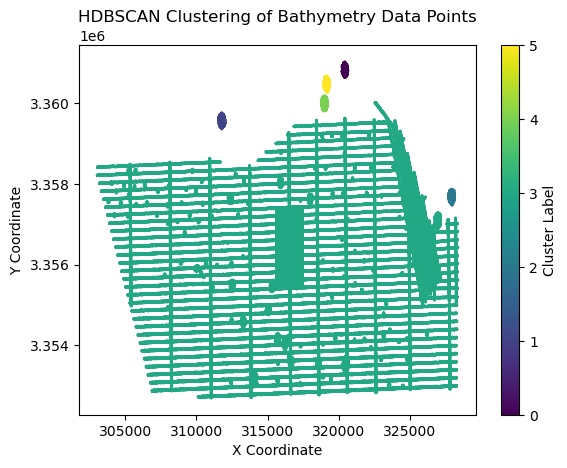

In [18]:
# plotting the clusters
from matplotlib import pyplot as plt
plt.scatter(X_subset[:, 0], X_subset[:, 1], c=labels_hdbscan, cmap='viridis', s=1)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('HDBSCAN Clustering of Bathymetry Data Points')
plt.colorbar(label='Cluster Label')
plt.show()

### Spectral Clustering

In [20]:
X = np.array(bathy_data_points[:, :2])  # Use only the x and y coordinates for clustering
subset = int(len(X) * 0.05)  # Use a subset of the data for faster computation
subset_indices = random.sample(range(len(X)), subset)
X_subset = X[subset_indices, :]

In [21]:
from sklearn.cluster import SpectralClustering
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=0)
labels = spectral.fit_predict(X_subset)


/opt/anaconda3/envs/interpolation_uncertainty/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


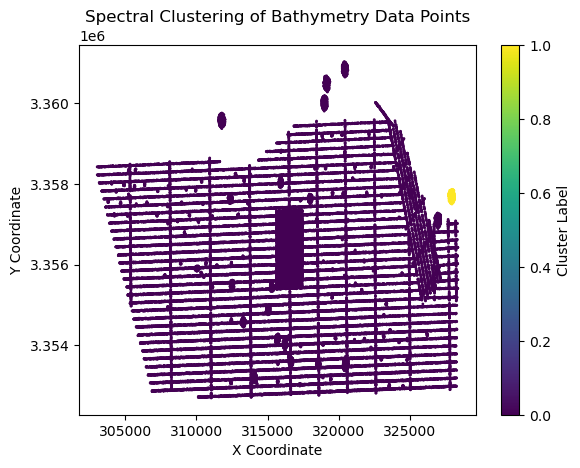

In [22]:
# plotting the clusters
plt.scatter(X_subset[:, 0], X_subset[:, 1], c=labels, cmap='viridis', s=1)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Spectral Clustering of Bathymetry Data Points')
plt.colorbar(label='Cluster Label')
plt.show()

### Distributions

In [ ]:
import math
import itertools

def angle_between_points(x1, y1, x2, y2):
    """
    Calculates the angle (in degrees) of the line from (x1, y1) 
    to (x2, y2) relative to the positive x-axis.
    """
    dx = x2 - x1
    dy = y2 - y1
    # atan2 takes y first, then x
    radians = math.atan2(dy, dx)
    degrees = math.degrees(radians)
    return degrees

distances = []
angles = []
points = X_subset.tolist()  # Convert to list of tuples for easier combinations
print(len(points))



13809


In [7]:
for p1, p2 in itertools.combinations(points, 2):
    # Calculate distance and angle for each pair
    distance = math.dist(p1, p2)
    angle = angle_between_points(p1[0], p1[1], p2[0], p2[1])
    distances.append(distance)
    angles.append(angle)

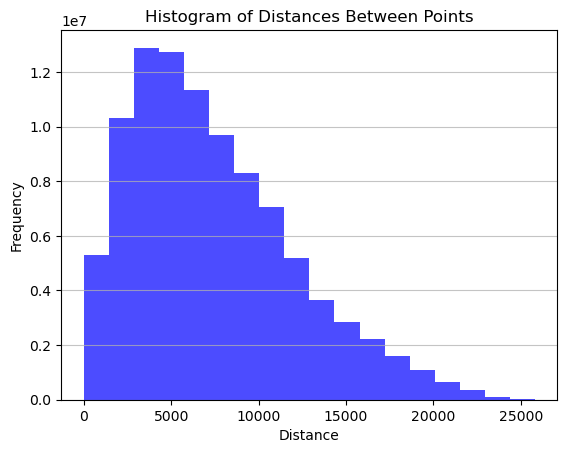

In [8]:
plt.hist(distances, bins=18, color='blue', alpha=0.7)
plt.title("Histogram of Distances Between Points")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)

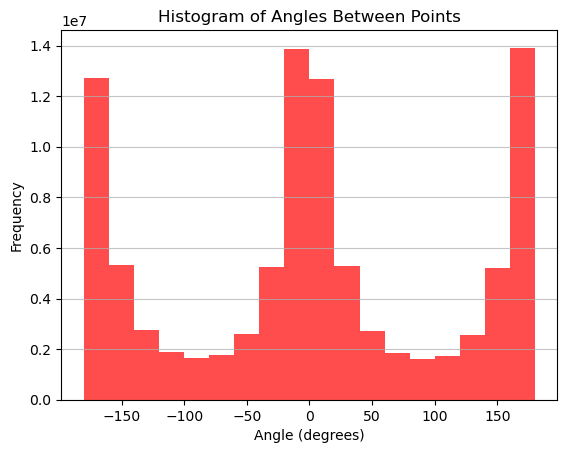

In [9]:
plt.hist(angles, bins=18, color='red', alpha=0.7)
plt.title("Histogram of Angles Between Points")
plt.xlabel("Angle (degrees)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)

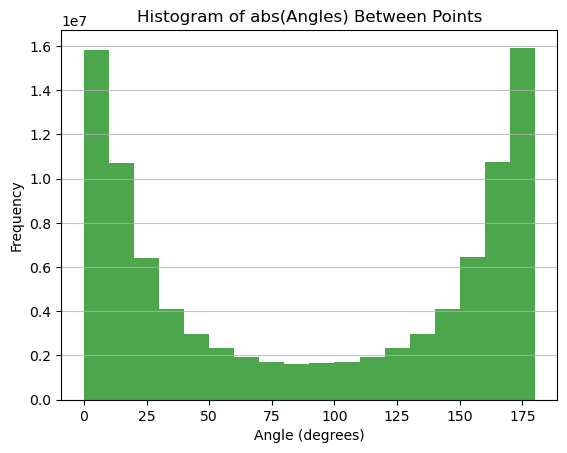

In [10]:
plt.hist(np.abs(angles), bins=18, color='green', alpha=0.7)
plt.title("Histogram of abs(Angles) Between Points")
plt.xlabel("Angle (degrees)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)

Text(0.5, 0, 'Distance')

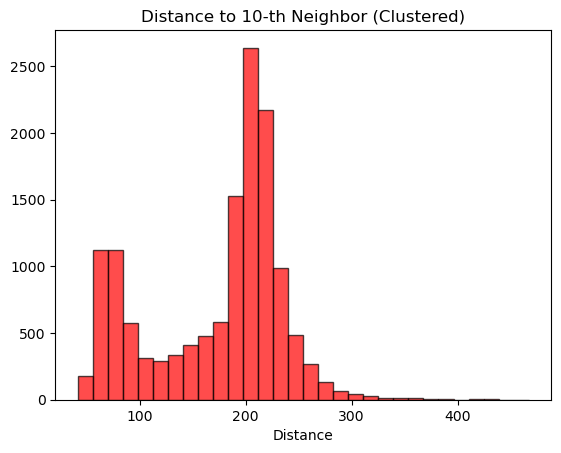

In [11]:
from scipy.spatial import KDTree

def get_knn_distances(points, k):
    tree = KDTree(points)
    # k+1 because the 1st neighbor (index 0) is the point itself
    distances, _ = tree.query(points, k=k+1)
    return distances[:, k]

dist_clustered = get_knn_distances(X_subset, k=10)

plt.hist(dist_clustered, bins=30, color='red', alpha=0.7, edgecolor='black')
plt.title(f"Distance to 10-th Neighbor (Clustered)")
plt.xlabel("Distance")


Text(0.5, 0, 'Distance')

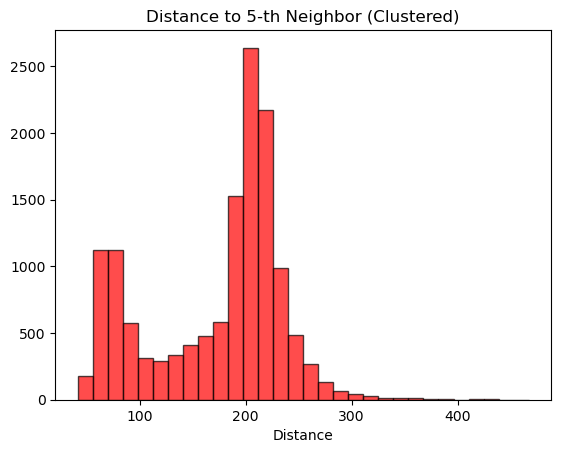

In [13]:
dist_clustered_5 = get_knn_distances(X_subset, k=5)

plt.hist(dist_clustered, bins=30, color='red', alpha=0.7, edgecolor='black')
plt.title(f"Distance to 5-th Neighbor (Clustered)")
plt.xlabel("Distance")

In [28]:
midpoint = 120
label_1_indices = np.where(dist_clustered_5 < midpoint)[0]
label_2_indices = np.where(dist_clustered_5 >= midpoint)[0]

In [29]:
X_density_1 = X_subset[label_1_indices, :]
X_density_2 = X_subset[label_2_indices, :]

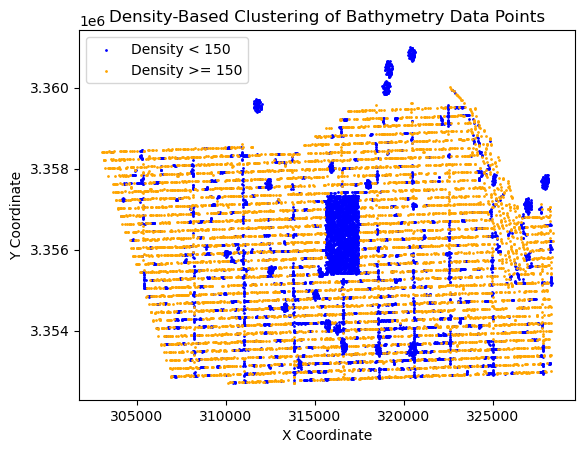

In [30]:
plt.scatter(X_density_1[:, 0], X_density_1[:, 1], color='blue', s=1, label='Density < 150')
plt.scatter(X_density_2[:, 0], X_density_2[:, 1], color='orange', s=1, label='Density >= 150')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Density-Based Clustering of Bathymetry Data Points')
plt.legend()

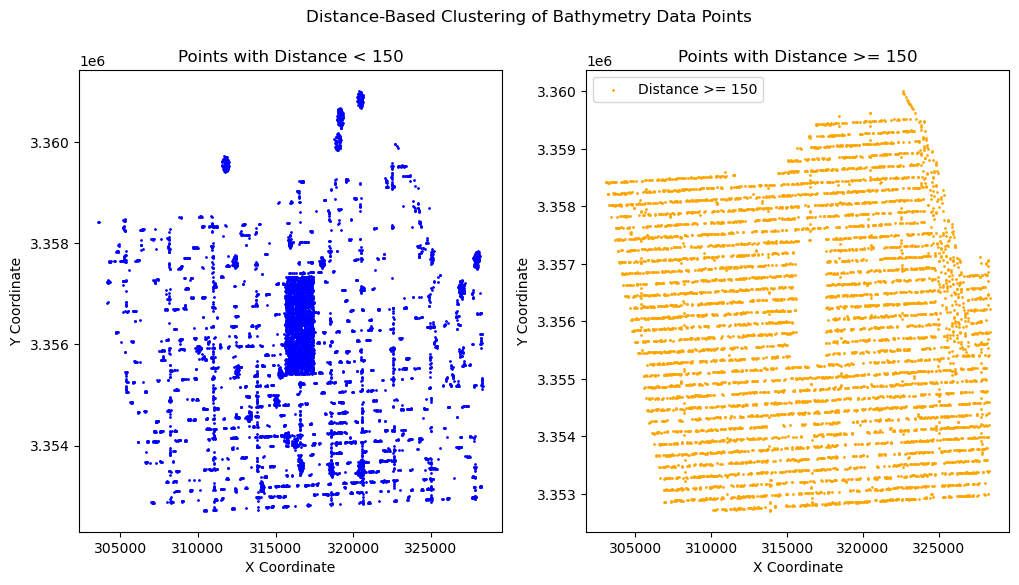

In [44]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_density_1[:, 0], X_density_1[:, 1], color='blue', s=1, label='Distance < 150')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Points with Distance < 150')

plt.subplot(1, 2, 2)
plt.scatter(X_density_2[:, 0], X_density_2[:, 1], color='orange', s=1, label='Distance >= 150')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Points with Distance >= 150')

plt.suptitle('Distance-Based Clustering of Bathymetry Data Points')
plt.legend()

In [31]:
len(X_subset), len(X)

(13809, 1380966)

Text(0, 0.5, 'Frequency')

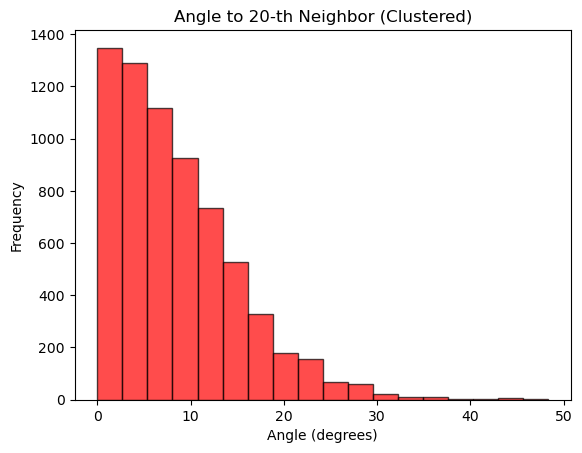

In [49]:
def get_knn_angles(points, k):
    tree = KDTree(points)
    angle_degrees = []
    _, indices = tree.query(points, k=k+1)
    for row in np.array(indices):
        cluster_points = points[row[:], :]
        line_of_best_fit = np.polyfit(cluster_points[:, 0], cluster_points[:, 1], 1)
        angle_radians = np.arctan(line_of_best_fit[0])
        angle_degrees.append(np.abs(np.degrees(angle_radians)))
    return angle_degrees

num_neighbors = 20
angle_clustered = get_knn_angles(X_density_2, k=num_neighbors)

plt.hist(angle_clustered, bins=18, color='red', alpha=0.7, edgecolor='black')
plt.title(f"Angle to {num_neighbors}-th Neighbor (Clustered)")
plt.xlabel("Angle (degrees)")
plt.ylabel("Frequency")

In [33]:
X_subset 

array([[ 320164., 3353276.],
       [ 323100., 3353304.],
       [ 316056., 3357328.],
       ...,
       [ 316580., 3355692.],
       [ 319924., 3357264.],
       [ 318592., 3352848.]], shape=(13809, 2))

### Using RANSAC

In [ ]:
from sklearn import linear_model

def get_knn_angles_with_RANSAC(points, k):
    tree = KDTree(points)
    ransac = linear_model.RANSACRegressor(
                min_samples=5,          
                residual_threshold=5,   
                max_trials=1000)
    # angle_degrees = []
    _, indices = tree.query(points, k=k+1)
    cluster_points = points[indices] # 13,000 points / rows
    print(cluster_points[0])
    angle_degrees = np.apply_along_axis(compute_angle_of_row, 1, cluster_points, k=k)
    return angle_degrees

def compute_angle_of_row(row, k):
    ransac = linear_model.RANSACRegressor(
                min_samples=k,   
                max_trials=1000)
    print(row)

    ## the main suspect  
    ransac.fit(row[:,0].reshape(-1, 1), row[:,1])

    # transforming the model to angle
    line_x = np.arange(row[:,0].min(), row[:,0].max())[:, np.newaxis]
    line_y_ransac = ransac.predict(line_x)
    line_of_best_fit = line_y_ransac
    angle_radians = np.arctan(line_of_best_fit[0])
    return np.abs(np.degrees(angle_radians))

num_neighbors = 20
angle_clustered_ransac = get_knn_angles_with_RANSAC(X_density_2, k=num_neighbors)

plt.hist(angle_clustered_ransac, bins=18, color='red', alpha=0.7, edgecolor='black')
plt.title(f"Angle to {num_neighbors}-th Neighbor (Clustered)")
plt.xlabel("Angle (degrees)")
plt.ylabel("Frequency")
plt.title(f"Histogram of Angles to {num_neighbors}-th Neighbor (Clustered) with RANSAC")


[[ 323100. 3353304.]
 [ 323192. 3353304.]
 [ 323236. 3353324.]
 [ 323108. 3353120.]
 [ 323288. 3353324.]
 [ 323080. 3353112.]
 [ 323052. 3353116.]
 [ 323080. 3353100.]
 [ 323112. 3353516.]
 [ 323128. 3353524.]
 [ 323252. 3353124.]
 [ 322856. 3353300.]
 [ 322840. 3353312.]
 [ 322928. 3353504.]
 [ 323376. 3353324.]
 [ 322900. 3353100.]
 [ 322880. 3353112.]
 [ 323300. 3353528.]
 [ 322816. 3353124.]
 [ 322832. 3353100.]
 [ 322828. 3353512.]]
[323100. 323192. 323236. 323108. 323288. 323080. 323052. 323080. 323112.
 323128. 323252. 322856. 322840. 322928. 323376. 322900. 322880. 323300.
 322816. 322832. 322828.]


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed